Calculating CRBs over SNR...
Calculating CRBs over Snapshots...
Done. Generating plots...


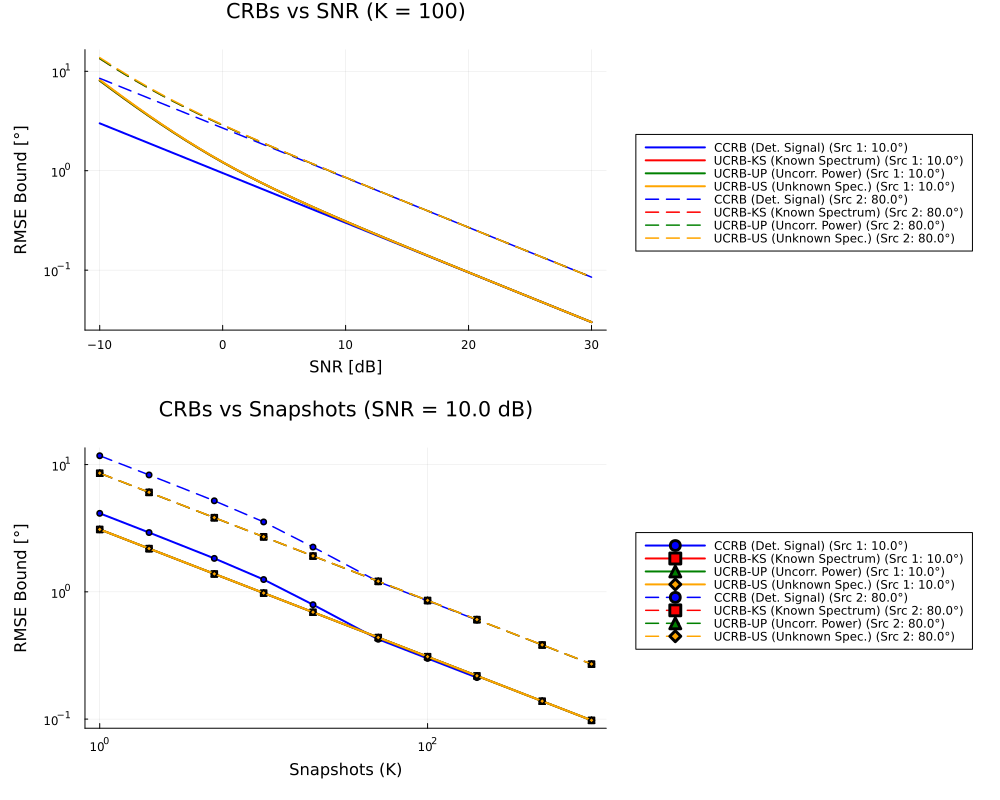

In [3]:
using ArraySignalProcessing
using LinearAlgebra
using Plots
import Measures

# --- Base Parameters ---
fc = 150e6
pa = IsotropicArray([0 0 0 0; -1.5 -0.5 0.5 1.5])

# Angles
true_angles_deg = [10.0, 80.0]
true_angles_rad = deg2rad.(true_angles_deg)
d = length(true_angles_rad)

# --- Signal Generator ---
function get_deterministic_signals(d, K)
    s = zeros(ComplexF64, d, K)
    amplitudes = [1.0, 2.0] # Amplitude 1 for Src 1, Amplitude 2 for Src 2
    for i in 1:d
        f_offset = 0.01 * i 
        s[i, :] .= amplitudes[i] .* exp.(1im * 2π * f_offset .* (0:(K-1)))
    end
    return s
end

# Signal variances (power) for the Gaussian source models
svar = [1.0^2, 2.0^2]
Rss = diagm(svar)

am_wrapper(θ) = pa(reshape(θ, 1, :), fc)
signal_power = sum(svar) / d

# --- Simulation 1: CRB over SNR (Fixed Snapshots) ---
snrs_db = collect(-10:30)
K_fixed = 100
s_fixed_K = get_deterministic_signals(d, K_fixed)

crb_snr_ccrb = zeros(length(snrs_db), d)
crb_snr_uks  = zeros(length(snrs_db), d)
crb_snr_uup  = zeros(length(snrs_db), d)
crb_snr_uus  = zeros(length(snrs_db), d)

println("Calculating CRBs over SNR...")

# Pre-compute CCRB at a baseline noise variance of 1.0 (0 dB).
# The DOA angle bounds scale linearly with noise variance.
c_cov_base = classical_crb_conditional_signal(s_fixed_K, 1.0, am_wrapper, true_angles_rad)

for (i, snr) in enumerate(snrs_db)
    nvar = signal_power / (10^(snr/10))
    
    # Scale the pre-computed CCRB linearly
    c_cov  = c_cov_base .* nvar
    
    # UCRBs cannot be scaled linearly over SNR (nvar is inside the matrix inverse)
    uk_cov = classical_crb_gaussian_signal_known_spectrum(Rss, nvar, am_wrapper, true_angles_rad, K_fixed)
    up_cov = classical_crb_gaussian_signal_unknown_power(svar, nvar, am_wrapper, true_angles_rad, K_fixed)
    us_cov = classical_crb_gaussian_signal_unknown_spectrum(Rss, nvar, am_wrapper, true_angles_rad, K_fixed)
    
    crb_snr_ccrb[i, :] .= rad2deg.(sqrt.(abs.(diag(c_cov)[1:d])))
    crb_snr_uks[i, :]  .= rad2deg.(sqrt.(abs.(diag(uk_cov)[1:d])))
    crb_snr_uup[i, :]  .= rad2deg.(sqrt.(abs.(diag(up_cov)[1:d])))
    crb_snr_uus[i, :]  .= rad2deg.(sqrt.(abs.(diag(us_cov)[1:d])))
end

# --- Simulation 2: CRB over Snapshots (Fixed SNR) ---
snapshots_sweep = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
snr_fixed = 10.0
nvar_fixed = signal_power / (10^(snr_fixed/10))

crb_K_ccrb = zeros(length(snapshots_sweep), d)
crb_K_uks  = zeros(length(snapshots_sweep), d)
crb_K_uup  = zeros(length(snapshots_sweep), d)
crb_K_uus  = zeros(length(snapshots_sweep), d)

println("Calculating CRBs over Snapshots...")

# Generate max signal length and crop it via views to save allocations
s_max_K = get_deterministic_signals(d, maximum(snapshots_sweep))

# UCRBs scale with 1/K. Compute ONCE for K=1.
uk_cov_1 = classical_crb_gaussian_signal_known_spectrum(Rss, nvar_fixed, am_wrapper, true_angles_rad, 1)
up_cov_1 = classical_crb_gaussian_signal_unknown_power(svar, nvar_fixed, am_wrapper, true_angles_rad, 1)
us_cov_1 = classical_crb_gaussian_signal_unknown_spectrum(Rss, nvar_fixed, am_wrapper, true_angles_rad, 1)

for (j, K) in enumerate(snapshots_sweep)
    s_k = @view s_max_K[:, 1:K]
    
    if K <= 200
        c_cov  = classical_crb_conditional_signal(s_k, nvar_fixed, am_wrapper, true_angles_rad)
        crb_K_ccrb[j, :] .= rad2deg.(sqrt.(abs.(diag(c_cov)[1:d])))
    else
        crb_K_ccrb[j, :] .= NaN # Prevent memory freeze for large K
    end
    
    # Scale UCRBs with 1/K
    crb_K_uks[j, :]  .= rad2deg.(sqrt.(abs.(diag(uk_cov_1 ./ K)[1:d])))
    crb_K_uup[j, :]  .= rad2deg.(sqrt.(abs.(diag(up_cov_1 ./ K)[1:d])))
    crb_K_uus[j, :]  .= rad2deg.(sqrt.(abs.(diag(us_cov_1 ./ K)[1:d])))
end

println("Done. Generating plots...")

# --- Plotting ---
colors = [:blue, :red, :green, :orange]
styles = [:solid, :dash] # Solid for Src1 (10°), Dash for Src2 (80°)
labels = ["CCRB (Det. Signal)", "UCRB-KS (Known Spectrum)", "UCRB-UP (Uncorr. Power)", "UCRB-US (Unknown Spec.)"]

# 1. SNR Plot
p_snr = plot(title="CRBs vs SNR (K = $K_fixed)", xlabel="SNR [dB]", ylabel="RMSE Bound [°]", 
             yaxis=:log10, margin=5*Measures.mm, legend=:outerright)

for src_idx in 1:d
    lbl_suffix = " (Src $src_idx: $(true_angles_deg[src_idx])°)"
    ls = styles[src_idx]
    lw = src_idx == 1 ? 2 : 1.5
    
    plot!(p_snr, snrs_db, crb_snr_ccrb[:, src_idx], label=labels[1]*lbl_suffix, color=colors[1], linestyle=ls, linewidth=lw)
    plot!(p_snr, snrs_db, crb_snr_uks[:, src_idx],  label=labels[2]*lbl_suffix, color=colors[2], linestyle=ls, linewidth=lw)
    plot!(p_snr, snrs_db, crb_snr_uup[:, src_idx],  label=labels[3]*lbl_suffix, color=colors[3], linestyle=ls, linewidth=lw)
    plot!(p_snr, snrs_db, crb_snr_uus[:, src_idx],  label=labels[4]*lbl_suffix, color=colors[4], linestyle=ls, linewidth=lw)
end

# 2. Snapshots Plot
p_K = plot(title="CRBs vs Snapshots (SNR = $(snr_fixed) dB)", xlabel="Snapshots (K)", ylabel="RMSE Bound [°]", 
           xaxis=:log10, yaxis=:log10, margin=5*Measures.mm, legend=:outerright)

for src_idx in 1:d
    lbl_suffix = " (Src $src_idx: $(true_angles_deg[src_idx])°)"
    ls = styles[src_idx]
    lw = src_idx == 1 ? 2 : 1.5
    
    plot!(p_K, snapshots_sweep, crb_K_ccrb[:, src_idx], label=labels[1]*lbl_suffix, color=colors[1], linestyle=ls, linewidth=lw, marker=:circle, markersize=3)
    plot!(p_K, snapshots_sweep, crb_K_uks[:, src_idx],  label=labels[2]*lbl_suffix, color=colors[2], linestyle=ls, linewidth=lw, marker=:square, markersize=3)
    plot!(p_K, snapshots_sweep, crb_K_uup[:, src_idx],  label=labels[3]*lbl_suffix, color=colors[3], linestyle=ls, linewidth=lw, marker=:utriangle, markersize=3)
    plot!(p_K, snapshots_sweep, crb_K_uus[:, src_idx],  label=labels[4]*lbl_suffix, color=colors[4], linestyle=ls, linewidth=lw, marker=:diamond, markersize=3)
end

# Combine plots horizontally
final_plot = plot(p_snr, p_K, layout=(2, 1), size=(1000, 800))
display(final_plot)